### 7-3. Pooling 계층

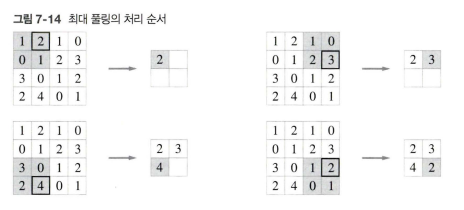
- (max Pooling)
###### 특정 영역의 원소를 하나로 집약하여 공간 크기를 줄인다.

---

### 7-4. 합성곱/Pooling 계층 구현하기

##### im2col(image to column)함수: filtering하기 좋게 입력 데이터를 펼치는 함수다.

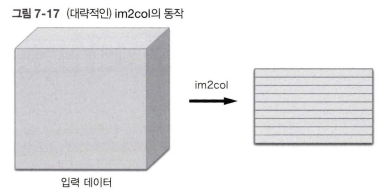

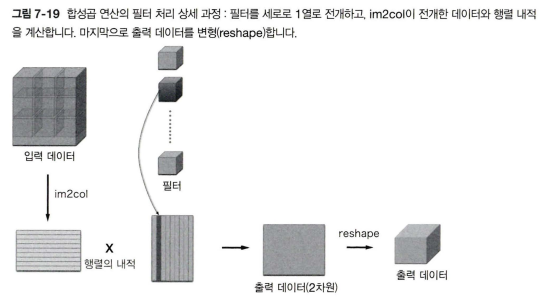

- 계산 순서(im2col로 입력 데이터 펼치기 -> 필터와 내적 -> 4차원 데이터로 reshape)

In [3]:
import sys, os
import numpy as np
sys.path.insert(
    0,
    os.path.abspath("../deeplearning_from_scratch")
)
from common.util import im2col


x1 = np.random.rand(1, 3, 7, 7) # (데이터수, 채널 수, 높이, 너비)
col1 = im2col(x1, 5, 5, stride = 1, pad = 0)
print(col1.shape)

x2 = np.random.rand(10, 3, 7, 7)
col2 = im2col(x2, 5, 5, stride = 1, pad = 0)
print(col2.shape)

(9, 75)
(90, 75)


In [ ]:
# convolution 계층(입력이든 필터든 정육면체를 펼쳐서 내적을 하고 다시 정육면체로 만든다고 생각)

class Convolution:
    def __init__(self, W, b, stride = 1, pad = 0): # 가중치, bias, stride, pad
        self.W = W
        self.b = b
        self.stride = stride
        self.pad = pad

    def forward(self, x):
        FN, C, FH, FW = self.W.shape # 필터개수, 채널, 필터 높이, 필터 너비
        N, C, H, W = x.shape
        out_h = int(1 + (H + 2*self.pad - FH) / self.stride)
        out_w = int(1 + (W + 2*self.pad - FW) / self.stride)

        col = im2col(x, FH, FW, self.stride, self.pad)
        col_W = self.W.reshape(FN, -1).T # 필터 전개
        print(col.shape)
        print(col_w.shape)
        out = np.dot(col,col_W) + self.b

        out = out.reshape(N, out_h, out_w, -1).transpose(0, 3, 1, 2)

        return out


In [ ]:
# 풀링 계층

import numpy as np

class Pooling:
    def __init__(self, pool_h, pool_w, stride =1, pad = 0):
        self.pool_h = pool_h
        self.pool_w = pool_w
        self.stride = stride
        self.pad = pad

    def forward(self, x):
        N, C, H, W = x.shape
        out_h = int(1 + (H - self.pool_h) / self.stride)
        out_w = int(1 + (W - self.pool_w) / self.stride)

        col = im2col(x, self.pool_h, self.pool_w, self.stride, self.pad)
        col = col.reshape(-1, self.pool_h*self.pool_w)

        out = np.max(col, axis = 1)

        out = out.reshape(N, out_h, out_w, C).transpose(0, 3, 1, 2)

        return out
